<a href="https://colab.research.google.com/github/nevita275/PCVK26_20_Triya/blob/main/Week6_20_Triya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PRAKTIKUM FILTER
# CELL IDENTITAS

In [54]:
NAMA = 'Nevita Triya Yuliana'
NIM  = '244107020208'
print(NAMA, NIM)

Nevita Triya Yuliana 244107020208


## Langkah 1: Fungsi konvolusi dari algoritma Bagian C (tanpa library/metode OpenCV)

In [55]:
def konvolusi_dasar(citra, kernel):
    H, W   = len(citra), len(citra[0])
    kh, kw = len(kernel), len(kernel[0])
    ph, pw = kh // 2, kw // 2                      # posisi tengah kernel
    hasil  = [[0] * W for _ in range(H)]

    for y in range(H):                             # For y = 0 to tinggi-1
        for x in range(W):                         # For x = 0 to lebar-1
            z = 0                                  # z(x,y) = 0
            for k1 in range(kh):
                for k2 in range(kw):
                    yy, xx = y + k1 - ph, x + k2 - pw
                    if 0 <= yy < H and 0 <= xx < W:            # di luar citra dianggap 0
                        z += kernel[k1][k2] * citra[yy][xx]
            hasil[y][x] = z
    return hasil

## Langkah 2b: Akses Drive & import library

In [56]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [57]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

## Langkah 2c: Fungsi konvolusi untuk citra

In [58]:
def konvolusi(image, kernel, padding='nol'):
    kh, kw = kernel.shape
    ph, pw = kh // 2, kw // 2
    H, W = image.shape
    img = image.astype(np.float64)

    if padding == 'abaikan':                       # solusi 1: piksel pinggir diabaikan
        out = img.copy()
        for y in range(ph, H - ph):
            for x in range(pw, W - pw):
                out[y, x] = np.sum(kernel * img[y-ph:y+ph+1, x-pw:x+pw+1])
        return out

    mode = 'edge' if padding == 'duplikasi' else 'constant'    # solusi 2 / 3
    padded = np.pad(img, ((ph, ph), (pw, pw)), mode=mode)

    out = np.zeros((H, W), dtype=np.float64)
    for y in range(H):
        for x in range(W):
            out[y, x] = np.sum(kernel * padded[y:y+kh, x:x+kw])
    return out

def ke_uint8(hasil):
    return np.clip(hasil, 0, 255).astype(np.uint8)

## Langkah 2d: Load citra (grayscale)

In [59]:
img = cv.imread('/content/drive/MyDrive/PVCK/Images/mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

## Langkah 2e: Tentukan kernel (contoh sharpening)

In [60]:
kernel_sharpen = np.array([[ 0, -1,  0],
                           [-1,  5, -1],
                           [ 0, -1,  0]])

## Langkah 2f: Panggil fungsi konvolusi & tampilkan hasil

Selisih maks vs cv.filter2D: 0


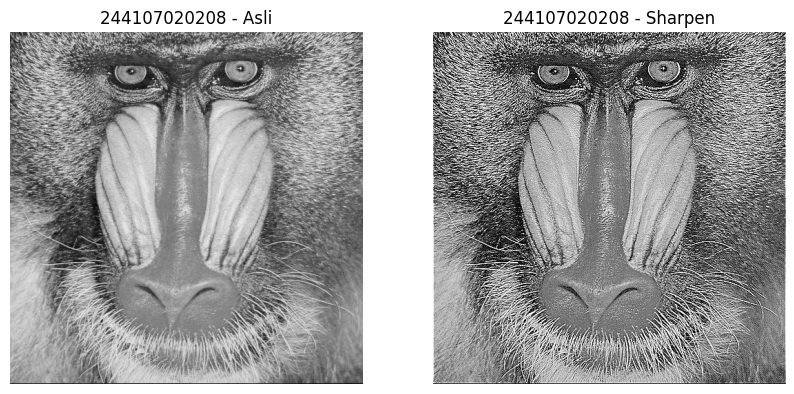

In [61]:
hasil = ke_uint8(konvolusi(img_gray, kernel_sharpen, padding='nol'))

# verifikasi terhadap OpenCV
ref = cv.filter2D(img_gray, -1, kernel_sharpen, borderType=cv.BORDER_CONSTANT)
print('Selisih maks vs cv.filter2D:', np.abs(hasil.astype(int) - ref.astype(int)).max())

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img_gray, cmap='gray'); ax[0].set_title(NIM + ' - Asli'); ax[0].axis('off')
ax[1].imshow(hasil, cmap='gray'); ax[1].set_title(NIM + ' - Sharpen'); ax[1].axis('off')
plt.show()

## Langkah 3: Average, Low Pass, High Pass, Sharpen, Emboss, Left Sobel, Canny, Gaussian 21x21

In [62]:
gray = img_gray

def convolution2d(image, kernel, stride=1, padding=0, mode='constant', bias=0, clip=True):
    """Adapter: membungkus konvolusi() milik Anda (padding nol) agar cocok dengan kode di bawah."""
    kernel = np.asarray(kernel, dtype=np.float64)
    p = kernel.shape[0] // 2
    if mode == 'edge':                                   # padding duplikasi tepi
        f = np.pad(image, p, mode='edge')
        hasil = konvolusi(f, kernel, padding='nol')[p:-p, p:-p]
    else:                                                # padding nol
        hasil = konvolusi(image, kernel, padding='nol')
    hasil = hasil[::stride, ::stride] + bias
    return ke_uint8(hasil) if clip else hasil

## Langkah 3a: Kernel dan tabel filter

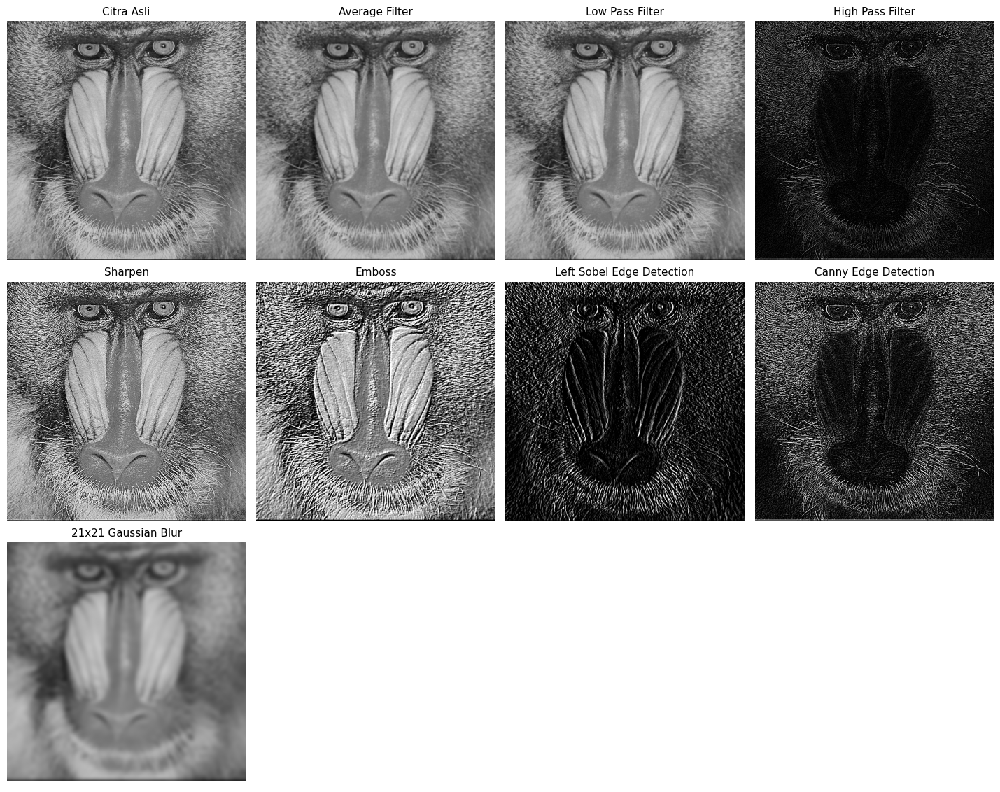

In [63]:
import math
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

# ===== 1. Definisi kernel =====
kernel_average    = np.ones((3, 3)) / 9
kernel_lowpass    = np.array([[1, 1, 1], [1, 4, 1], [1, 1, 1]]) / 12
kernel_highpass   = np.array([[0, -1, 0], [-1, 4, -1], [0, -1, 0]])
kernel_sharpen    = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
kernel_emboss     = np.array([[-2, -1, 0], [-1, 1, 1], [0, 1, 2]])
kernel_sobel_left = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]])
kernel_edge       = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]])

kernel_size = 21
sigma = math.sqrt(kernel_size)
g1 = cv.getGaussianKernel(kernel_size, sigma)
gauss_kernel = g1 @ g1.T

# ===== 2. Fungsi konvolusi =====
def convolution2d(image, kernel, stride=1, padding=0, mode='edge', bias=0):
    kh, kw = kernel.shape
    img = np.pad(image.astype(np.float64), ((padding, padding), (padding, padding)), mode=mode)
    H, W = image.shape
    out = np.zeros((H, W))
    for y in range(0, H, stride):
        for x in range(0, W, stride):
            out[y, x] = np.sum(kernel * img[y:y+kh, x:x+kw]) + bias
    return np.clip(out, 0, 255).astype(np.uint8)

# ===== 3. Daftar filter: (nama, kernel, bias) =====
daftar_filter = [
    ('Average Filter',            kernel_average,    0),
    ('Low Pass Filter',           kernel_lowpass,    0),
    ('High Pass Filter',          kernel_highpass,   0),
    ('Sharpen',                   kernel_sharpen,    0),
    ('Emboss',                    kernel_emboss,     0),
    ('Left Sobel Edge Detection', kernel_sobel_left, 0),
    ('Canny Edge Detection',      kernel_edge,       0),
    ('21x21 Gaussian Blur',       gauss_kernel,      0),
]

# ===== 4. Tampilkan menyamping =====
def tampil_filter(img_gray, daftar, ncols=4, simpan_png=True):
    n = len(daftar) + 1                                   # +1 untuk citra asli
    nrows = math.ceil(n / ncols)
    fig, ax = plt.subplots(nrows, ncols, figsize=(3.6 * ncols, 3.8 * nrows))
    ax = np.array(ax).reshape(-1)
    for a in ax:
        a.axis('off')

    ax[0].imshow(img_gray, cmap='gray', vmin=0, vmax=255)
    ax[0].set_title('Citra Asli', fontsize=11)

    for i, (nama, kernel, bias) in enumerate(daftar, start=1):
        hasil = convolution2d(img_gray, kernel, stride=1, padding=kernel.shape[0] // 2, mode='edge', bias=bias)
        ax[i].imshow(hasil, cmap='gray', vmin=0, vmax=255)
        ax[i].set_title(nama, fontsize=11)

    plt.tight_layout()
    if simpan_png:
        fig.savefig('hasil_filter.png', dpi=150, bbox_inches='tight')
    plt.show()

# ===== 5. Panggil =====
tampil_filter(img_gray, daftar_filter, ncols=4)

# FILTER LIBRARY DAN FILTER MODERN
## Percobaan 1:


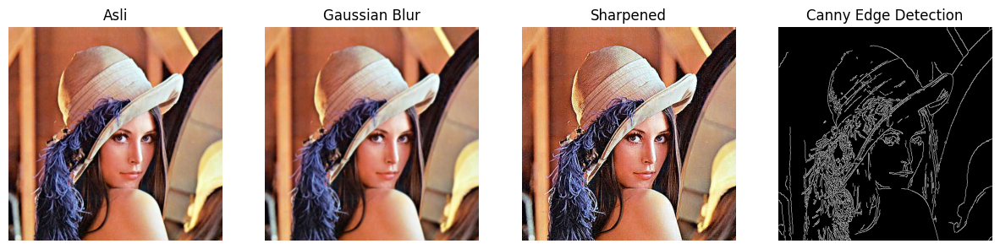

In [64]:
# Fungsi tampil berdampingan
def show_side_by_side(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:  # grayscale
            plt.subplot(1, len(images), i+1)
            plt.imshow(img, cmap="gray")
        else:  # color
            plt.subplot(1, len(images), i+1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()


img = cv.imread("/content/drive/MyDrive/PVCK/Images/lena.jpg")
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7,7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)

show_side_by_side([img, blur, sharpened, edges],
                  ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])

## Percobaan 2:

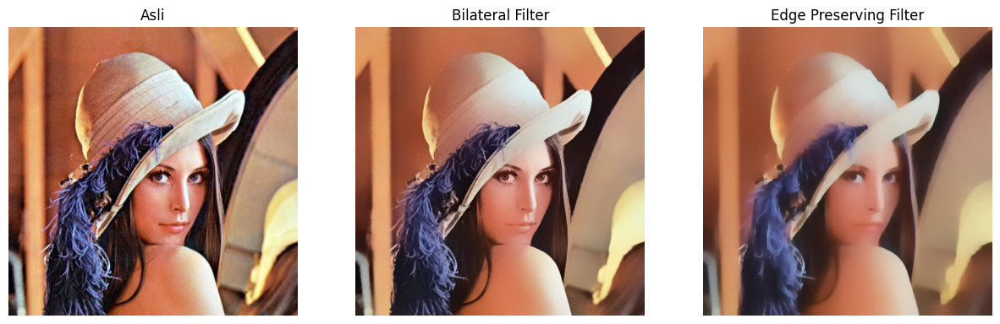

In [65]:
# Filter Modern dari OpenCV
# Bilateral Filter (edge-preserving)
bilateral = cv.bilateralFilter(img, 50, 100, 100)

# Edge Preserving Filter (alternatif Guided Filter)
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserve],
                  ["Asli", "Bilateral Filter", "Edge Preserving Filter"])

## Percobaan 3:

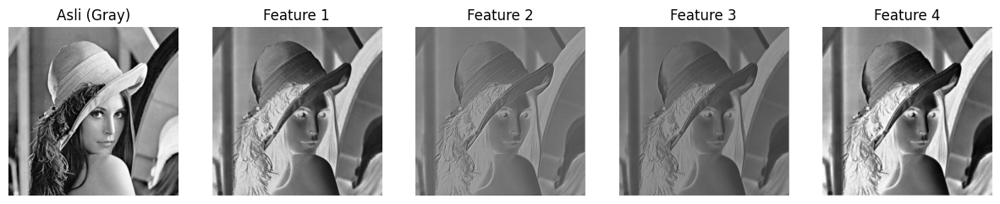

In [66]:
# Filter Feature Map yang digunakan pada CNN, lakukan running code bagian ini beberapa kali dan perhatikan hasilnya
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)

model = SimpleCNN()

# Ubah gambar ke tensor
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

# Hasil CNN
with torch.no_grad():
    features = model(img_tensor)

# Visualisasi feature maps
feature_maps = [features[0, i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray] + feature_maps,
                  ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))])

## Percobaan 4:

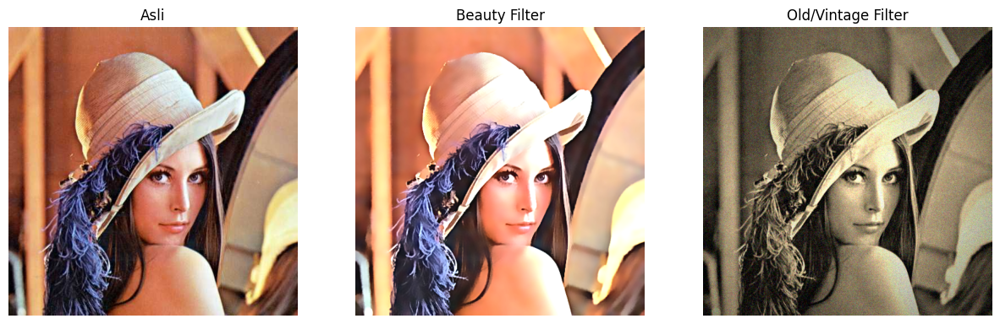

In [67]:
# ====================
# 1. Beauty Filter
# ====================
# Step 1: Smoothing kulit dengan bilateral filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

# Step 2: Unsharp masking (pertajam mata/bibir)
gaussian = cv.GaussianBlur(smooth, (0,0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

# Step 3: Brightness & contrast
alpha = 1.2  # contrast
beta = 15    # brightness
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)


# ====================
# 2. Old/Vintage Filter
# ====================
# Step 1: Sepia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])

sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# Step 2: Vignette
rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols*0.6)
kernel_y = cv.getGaussianKernel(rows, rows*0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()

vignette = np.copy(sepia)
for i in range(3):
    vignette[:,:,i] = vignette[:,:,i] * mask

# Step 3: Noise/Grain
noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(
    vignette.astype(np.int16) + noise,
    0,
    255
).astype(np.uint8)


# ====================
# Tampilkan hasil
# ====================
show_side_by_side(
    [img, beauty, old_img],
    ["Asli", "Beauty Filter", "Old/Vintage Filter"]
)

## Percobaan 5:

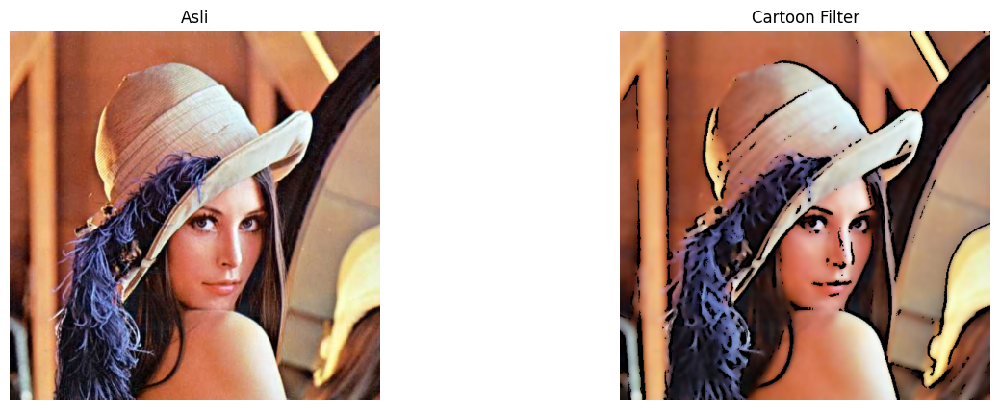

In [68]:
# Filter Anime / Cartoon
# Step 1: Edge detection (pakai median blur dulu agar gambar menjadi lebih halus)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255,
                             cv.ADAPTIVE_THRESH_MEAN_C,
                             cv.THRESH_BINARY, 9, 9)

# Step 2: Bilateral Filter untuk smooth warna
color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

# Step 3: Gabungkan (cartoonize)
cartoon = cv.bitwise_and(color, color, mask=edges)

# Tampilkan
show_side_by_side([img, cartoon], ["Asli", "Cartoon Filter"])

## Percobaan 6:

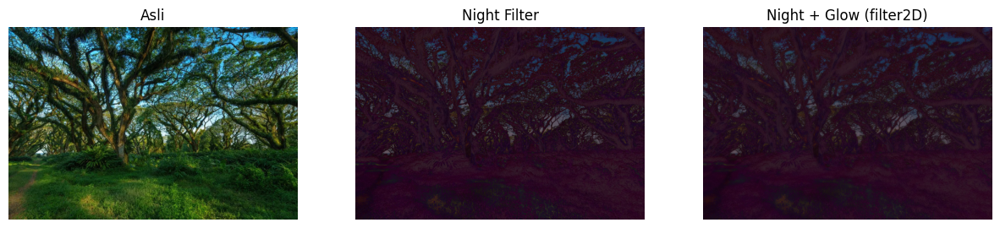

In [69]:
# Night Filter
img = cv.imread("/content/drive/MyDrive/PVCK/Images/djawatan.jpg")

# Step 1: Gelapkan (transisi kontras negatif)
night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)

# Step 2: Tambah bias biru
blue_tint = np.full_like(night, (50, 0, 100))  # BGR
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# Step 3: Efek Glow di area terang dengan filter2D (blur kernel)
kernel = np.ones((15,15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)

# Kombinasikan asli + glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side(
    [img, night, night_glow],
    ["Asli", "Night Filter", "Night + Glow (filter2D)"]
)

## Percobaan 7:

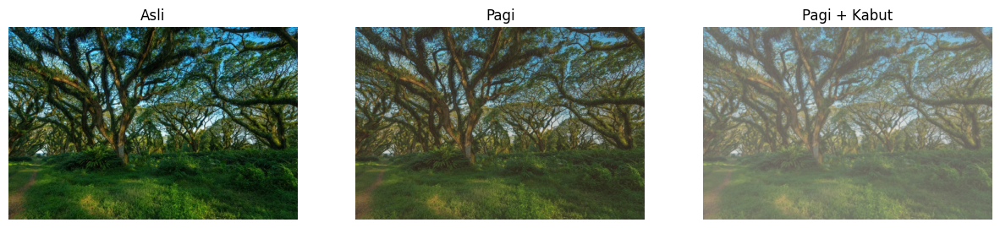

In [70]:
# Filter Suasana pagi dan Kabut
# =============================

# Step 1: Kurangi kontras & cerahkan
# =============================
alpha = 0.9      # contrast
beta = 20        # brightness
soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

# =============================
# Step 2: Tambahkan warm tone (kemerahan / oranye)
# =============================
warm_tint = np.full_like(soft, (40, 70, 120))  # BGR
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

# =============================
# Step 3: Tambahkan haze (kabut tipis) dengan filter2D
# =============================
# Kernel blur Gaussian-like untuk menciptakan efek kabut
kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T  # jadikan 2D kernel
kabut = cv.filter2D(pagi, -1, kernel)

# tambah layer putih untuk kabut lebih nyata
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img, pagi, kabut],
                  ["Asli", "Pagi", "Pagi + Kabut"])

# TUGAS PRAKTIKUM
## 1. Tugas Analisis: Perbandingan Mean Filter (Blur Biasa) vs. Median Filter pada Noise “Salt and Pepper”
### 1a dan 1b

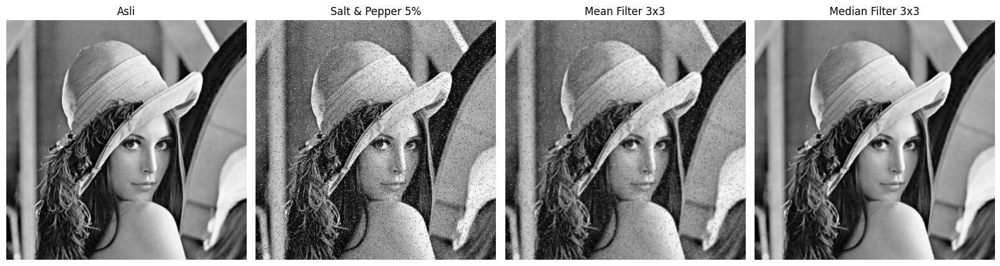

Citra                       MSE    PSNR (dB)
Noisy                   1014.50        18.07
Mean 3x3                 166.94        25.91
Median 3x3                31.43        33.16


In [71]:
# a. Tambahkan noise bintik hitam-putih (Salt and Pepper) ke sebuah citra keabuan (grayscale).

def salt_pepper(img, amount=0.05, seed=42):
    rng = np.random.default_rng(seed)
    out = img.copy()
    r = rng.random(img.shape)
    out[r < amount / 2] = 0
    out[r > 1 - amount / 2] = 255
    return out

# b. Terapkan Mean Filter(3 x 3) dan Median Filter (3 x 3).

def median_filter(img, k=3):
    p = k // 2
    fp = np.pad(img, p, mode='edge')
    H, W = img.shape
    tumpukan = [fp[i:i + H, j:j + W] for i in range(k) for j in range(k)]
    return np.median(np.stack(tumpukan), axis=0).astype(np.uint8)

def mse(a, b):  return np.mean((a.astype(np.float64) - b.astype(np.float64)) ** 2)
def psnr(a, b): return 10 * np.log10(255 ** 2 / mse(a, b))

noisy   = salt_pepper(img_gray, 0.05)
mean3   = convolution2d(noisy, np.ones((3, 3)) / 9, stride=1, padding=1, mode='edge')
median3 = median_filter(noisy, 3)

fig, ax = plt.subplots(1, 4, figsize=(16, 4.2))
for a, im, judul in zip(ax, [img_gray, noisy, mean3, median3],
                         ['Asli', 'Salt & Pepper 5%', 'Mean Filter 3x3', 'Median Filter 3x3']):
    a.imshow(im, cmap='gray', vmin=0, vmax=255); a.set_title(judul); a.axis('off')
plt.tight_layout(); plt.show()

print(f"{'Citra':20s} {'MSE':>10s} {'PSNR (dB)':>12s}")
for nama, im in [('Noisy', noisy), ('Mean 3x3', mean3), ('Median 3x3', median3)]:
    print(f'{nama:20s} {mse(img_gray, im):10.2f} {psnr(img_gray, im):12.2f}')

### 1c. Amati dan analisis secara visual mengapa Median Filter jauh lebih bersih dalam menghapus noise tersebut dibanding Mean Filter.

**Jawab: Berdasarkan hasil visual, Median Filter 3x3 lebih bersih dalam menghilangkan noise Salt and Pepper dibandingkan Mean Filter. Mean Filter menghitung rata-rata 9 piksel sehingga nilai ekstrem 0 atau 255 ikut memengaruhi hasil dan menyebabkan gambar menjadi lebih buram. Sedangkan Median Filter mengambil nilai tengah setelah mengurutkan 9 piksel, sehingga noise 0 atau 255 tidak banyak memengaruhi hasil dan tepi objek tetap lebih tajam. Hasilnya juga didukung oleh nilai MSE Median 31,43 dan PSNR 33,16 dB, yang lebih baik dibandingkan Mean dengan MSE 166,94 dan PSNR 25,91 dB.**


## 2. Tugas Evaluasi: Pemilihan Ukuran Kernel terbaik untuk Menajamkan Citra (Sharpening)

### 2a

In [72]:
# a. Buat kernel penajaman (Sharpening Kernel) ukuran 3 x 3 dan 5 x 5.

kernel_sharp3 = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
], dtype=np.float64)

kernel_sharp5 = -1/256 * np.array([
    [1,  4,    6,  4, 1],
    [4, 16,   24, 16, 4],
    [6, 24, -476, 24, 6],
    [4, 16,   24, 16, 4],
    [1,  4,    6,  4, 1]
], dtype=np.float64)

print(
    'Jumlah kernel 3x3 =',
    kernel_sharp3.sum(),
    '| Jumlah kernel 5x5 =',
    round(kernel_sharp5.sum(), 6)
)

Jumlah kernel 3x3 = 1.0 | Jumlah kernel 5x5 = 1.0


### 2b

In [73]:
# b. Terapkan pada citra yang sedikit buram (blurry).

blur_bersih = cv.GaussianBlur(img_gray, (0, 0), 1.5)

rng = np.random.default_rng(0)
noise = rng.normal(0, 3, img_gray.shape)
blur_noise = np.clip(
    blur_bersih + noise,
    0,
    255
).astype(np.uint8)

# Terapkan kernel sharpening
s3_bersih = convolution2d(
    blur_bersih,
    kernel_sharp3,
    1,
    1,
    'edge'
)

s5_bersih = convolution2d(
    blur_bersih,
    kernel_sharp5,
    1,
    2,
    'edge'
)

# Terapkan sharpening pada citra buram + noise
s3_noise = convolution2d(
    blur_noise,
    kernel_sharp3,
    1,
    1,
    'edge'
)

s5_noise = convolution2d(
    blur_noise,
    kernel_sharp5,
    1,
    2,
    'edge'
)

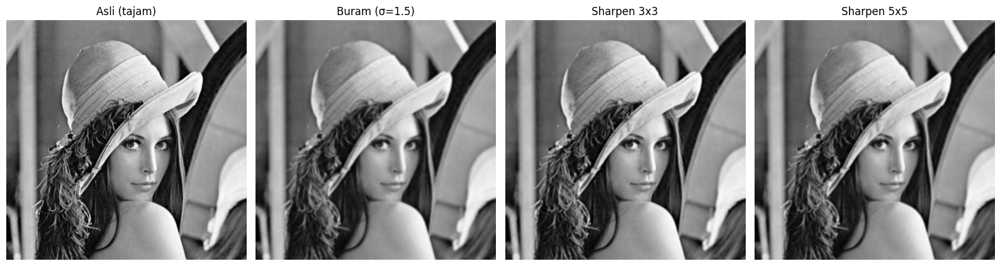

In [74]:
# Hasil penerapan kernel:
fig, ax = plt.subplots(1, 4, figsize=(16, 4.2))

for a, im, judul in zip(
    ax,
    [img_gray, blur_bersih, s3_bersih, s5_bersih],
    ['Asli (tajam)', 'Buram (σ=1.5)', 'Sharpen 3x3', 'Sharpen 5x5']
):
    a.imshow(im, cmap='gray', vmin=0, vmax=255)
    a.set_title(judul)
    a.axis('off')

plt.tight_layout()
plt.show()

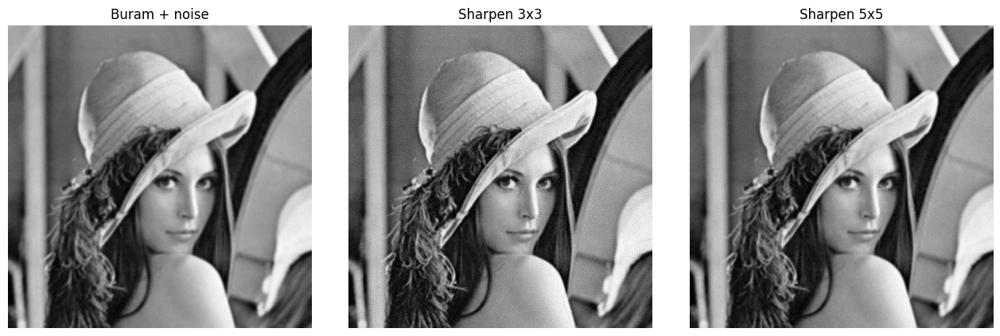

In [75]:
# Melihat efeknya ketika ada noise
fig, ax = plt.subplots(1, 3, figsize=(13, 4.2))

for a, im, judul in zip(
    ax,
    [blur_noise, s3_noise, s5_noise],
    ['Buram + noise', 'Sharpen 3x3', 'Sharpen 5x5']
):
    a.imshow(im, cmap='gray', vmin=0, vmax=255)
    a.set_title(judul)
    a.axis('off')

plt.tight_layout()
plt.show()

## 2c. Evaluasi hasilnya berdasarkan aspek Kejelasan Tepi vs. Kadar Noise/Noise Distortion yang dihasilkan. Tentukan kernel mana yang paling optimal untuk digunakan sehari-hari.
**Jawab: Berdasarkan hasil pengamatan, Sharpening 3×3 dan 5×5 sama-sama meningkatkan kejelasan tepi citra yang sebelumnya buram. Kernel 3×3 menghasilkan tepi yang cukup tajam dengan detail yang masih terlihat natural, sedangkan kernel 5×5 memberikan penajaman yang lebih kuat tetapi cenderung menghasilkan noise atau distorsi lebih banyak, terutama pada citra yang mengandung noise. Jadi, untuk penggunaan sehari-hari kernel 3×3 lebih sesuai digunakan karena memberikan keseimbangan antara ketajaman tepi dan tingkat noise yang dihasilkan. Kernel 5×5 dapat digunakan ketika diperlukan penajaman yang lebih kuat, tetapi risikonya adalah noise dan artefak pada citra menjadi lebih terlihat.**

## 3. Tugas Kreasi: Filter Kartun Sederhana
### 3a

In [76]:
# a. Buatlah sebuah fungsi kustom bernama kartun(image) yang menggabungkan:
# * Penghalusan warna menggunakan **Bilateral Filter** agar area warna menjadi rata.
# * Deteksi garis tepi menggunakan **Adaptive Thresholding** atau **Canny Edge**.
# * Penggabungan (kombinasi) keduanya menggunakan operasi logika/perkalian piksel.
# Jawab:

img_lena = cv.imread("/content/drive/MyDrive/PVCK/Images/lena.jpg")

def kartun(image, metode='adaptive', n_bilateral=5, gabung='and'):
    # Penghalusan warna dengan Bilateral Filter
    warna = image.copy()

    for _ in range(n_bilateral):
        warna = cv.bilateralFilter(
            warna,
            d=9,
            sigmaColor=75,
            sigmaSpace=75
        )

    # Ubah ke grayscale dan haluskan
    g = cv.medianBlur(
        cv.cvtColor(image, cv.COLOR_BGR2GRAY),
        7
    )

    # Deteksi tepi
    if metode == 'adaptive':
        tepi = cv.adaptiveThreshold(
            g,
            255,
            cv.ADAPTIVE_THRESH_MEAN_C,
            cv.THRESH_BINARY,
            9,
            8
        )

    elif metode == 'canny':
        e = cv.Canny(g, 80, 160)
        e = cv.dilate(e, np.ones((2, 2), np.uint8))
        tepi = cv.bitwise_not(e)

    else:
        raise ValueError("metode: 'adaptive' atau 'canny'")

    # Ubah tepi grayscale menjadi 3 channel
    tepi3 = cv.cvtColor(tepi, cv.COLOR_GRAY2BGR)

    # Gabungkan warna dan tepi
    if gabung == 'and':
        return cv.bitwise_and(warna, tepi3)

    return (
        warna.astype(np.float32) *
        (tepi3.astype(np.float32) / 255.0)
    ).astype(np.uint8)

### 3b

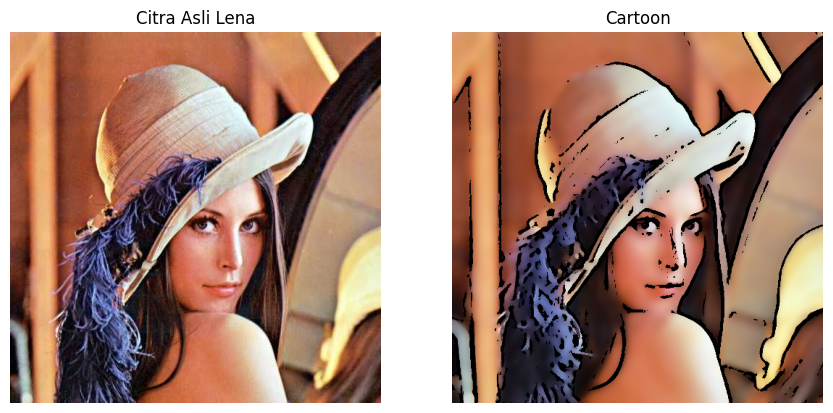

In [77]:
# b. Tampilkan hasil citra asli dengan citra efek kartun bersebelahan.

hasil_kartun_lena = kartun(img_lena)

fig, ax = plt.subplots(1, 2, figsize=(9, 4.2))

for a, im, judul in zip(
    ax,
    [img_lena, hasil_kartun_lena],
    ['Citra Asli Lena', 'Cartoon']
):
    a.imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB))
    a.set_title(judul)
    a.axis('off')

plt.tight_layout()
plt.show()